<a href="https://colab.research.google.com/github/Owusuk/Projects/blob/main/JPMorgan_Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import plotly.express as px

%matplotlib inline
sns.set_style('darkgrid')
sns.set_palette('rainbow')
sns.set_palette('Set2')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Task 3 and 4_Loan_Data.csv to Task 3 and 4_Loan_Data.csv


In [36]:
Loan_Data_df = pd.read_csv("Task 3 and 4_Loan_Data.csv")
Loan_Data_df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


1. **Data Preparation**:
   - Loaded the data from the CSV file (Already uploaded).
   - Defined the feature columns (`credit_lines_outstanding`, `loan_amt_outstanding`, `total_debt_outstanding`, `income`, `years_employed`, `fico_score`) and the target column (`default`).

In [37]:
Loan_Data_df.drop('customer_id', axis=1, inplace=True)
Loan_Data_df.describe()

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [38]:
Loan_Data_df.duplicated().sum()

np.int64(0)

In [39]:
Loan_Data_df.isnull().sum()

,0
credit_lines_outstanding,0
loan_amt_outstanding,0
total_debt_outstanding,0
income,0
years_employed,0
fico_score,0
default,0


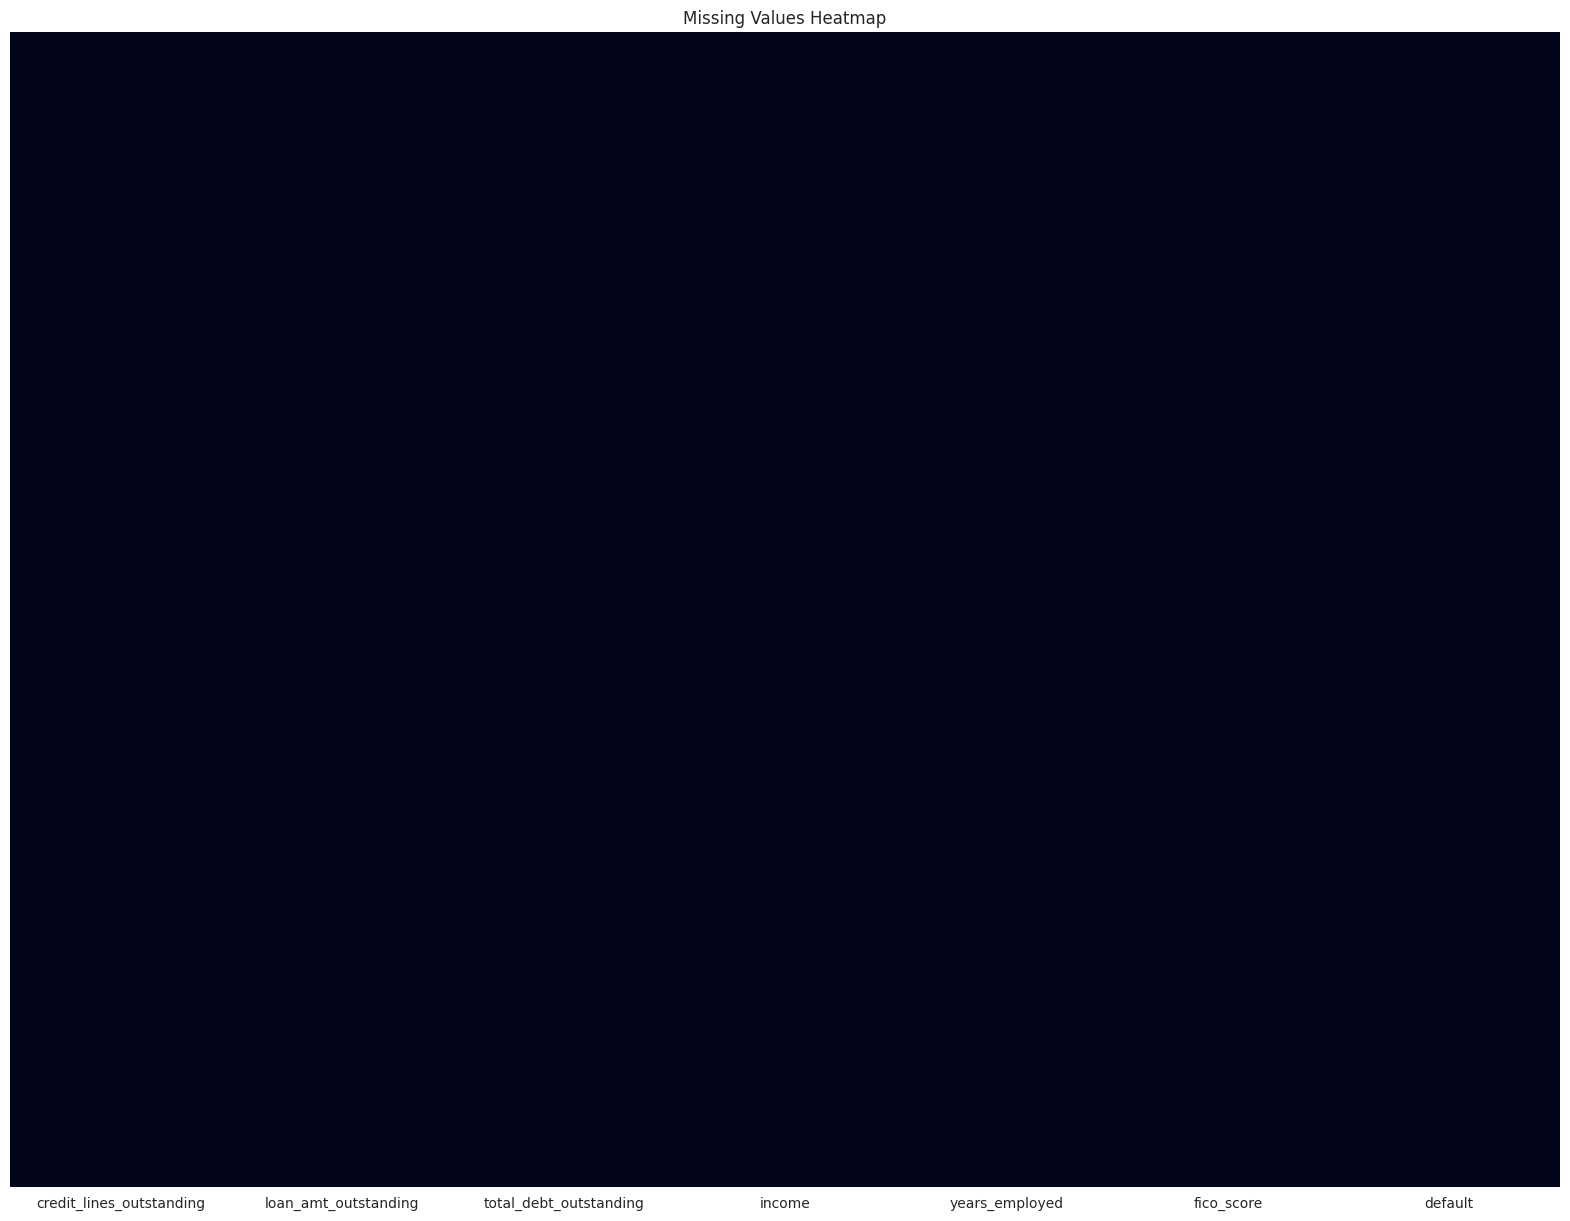

In [40]:
plt.figure(figsize=(20, 15))
sns.heatmap(Loan_Data_df.isnull(), yticklabels=False, cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [41]:
Loan_Data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   credit_lines_outstanding  10000 non-null  int64  
 1   loan_amt_outstanding      10000 non-null  float64
 2   total_debt_outstanding    10000 non-null  float64
 3   income                    10000 non-null  float64
 4   years_employed            10000 non-null  int64  
 5   fico_score                10000 non-null  int64  
 6   default                   10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 547.0 KB


In [42]:
Corr_Matrix = Loan_Data_df.corr()
Corr_Matrix

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
credit_lines_outstanding,1.000000,0.080249,0.852210,0.022272,-0.087900,-0.258177,0.862815
loan_amt_outstanding,0.080249,1.000000,0.397403,0.835815,-0.158416,-0.031373,0.098978
total_debt_outstanding,0.852210,0.397403,1.000000,0.394397,-0.174353,-0.232246,0.758868
income,0.022272,0.835815,0.394397,1.000000,0.001814,-0.010528,0.016309
years_employed,-0.087900,-0.158416,-0.174353,0.001814,1.000000,0.255873,-0.284506
fico_score,-0.258177,-0.031373,-0.232246,-0.010528,0.255873,1.000000,-0.324515
default,0.862815,0.098978,0.758868,0.016309,-0.284506,-0.324515,1.000000


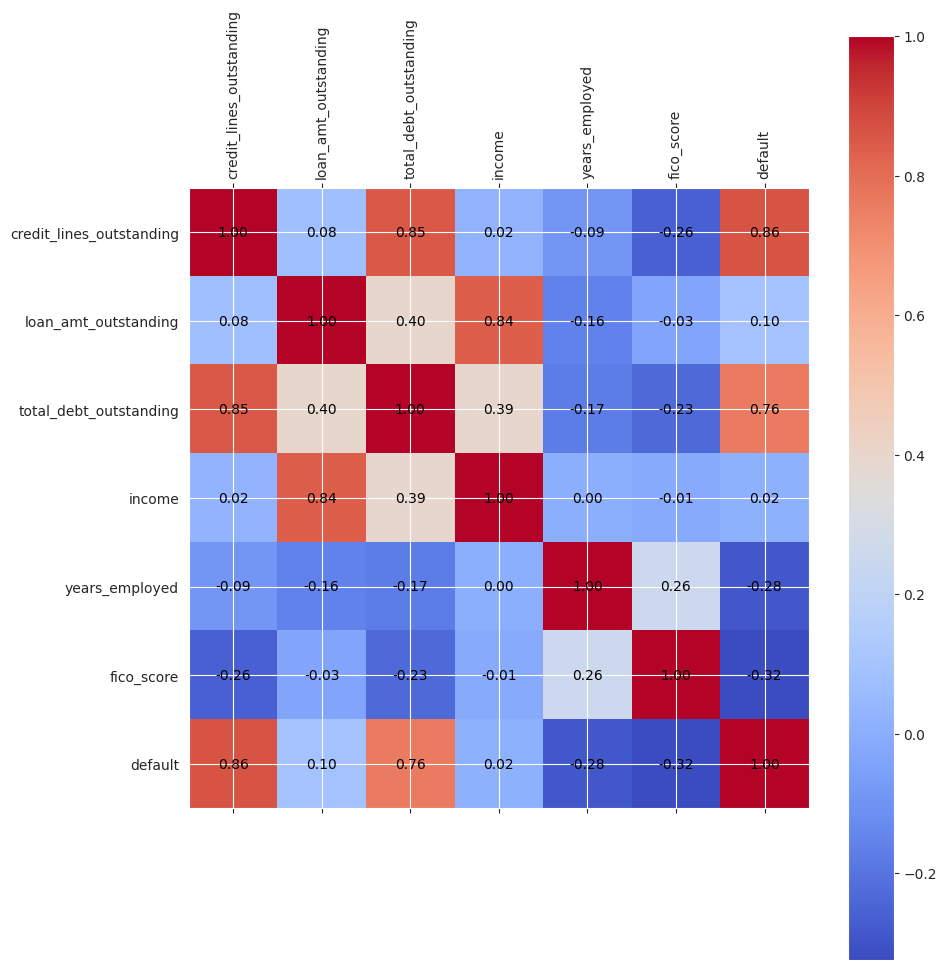

In [43]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 12))

# Display correlation matrix as heatmap
cax = ax.matshow(Corr_Matrix, cmap="coolwarm")

# Add color bar
fig.colorbar(cax)

# Set tick labels
ax.set_xticks(np.arange(len(Corr_Matrix.columns)))
ax.set_yticks(np.arange(len(Corr_Matrix.columns)))
ax.set_xticklabels(Corr_Matrix.columns, rotation=90)
ax.set_yticklabels(Corr_Matrix.columns)

# Annotate matrix with correlation values
for i in range(len(Corr_Matrix.columns)):
    for j in range(len(Corr_Matrix.columns)):
        ax.text(j, i, f"{Corr_Matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")

# Show plot
plt.show()

2. **Model Training**:
   - Split the data into training and testing sets.
   - Initialized a `RandomForestClassifier` model.
   - Trained the model using the training data.

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

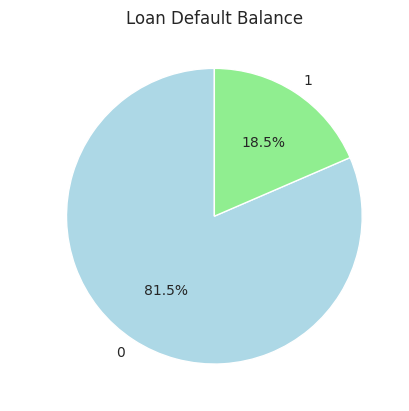

In [45]:
# Target value balance
Loan_Data_df['default'].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightblue", "lightgreen", "salmon", "lightcoral"]
)
plt.title("Loan Default Balance")
plt.ylabel(" ")
plt.show()

***There is imbalance in the datasets and would require models that are robust to deal with imbalance. Deploying stratification for training the data will ensure minority class ("Yes") is fairly represented.***

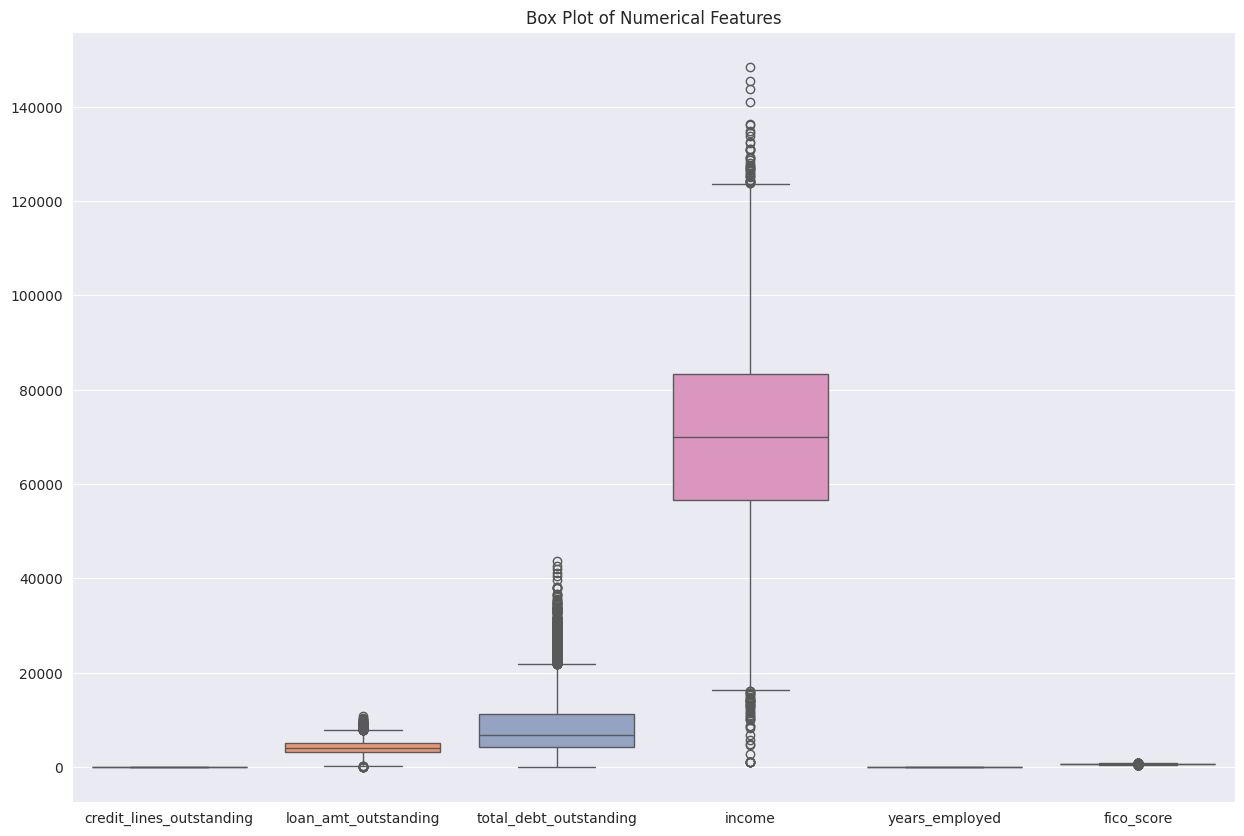

In [48]:
# Box Plot to assess outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=Loan_Data_df[['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']])
plt.title('Box Plot of Numerical Features')
plt.show()

In [49]:
#@title Outlier Detection and Removal (total_debt_outstanding & income)

q1 = Loan_Data_df[['total_debt_outstanding', 'income']].quantile(0.25)
q3 = Loan_Data_df[['total_debt_outstanding', 'income']].quantile(0.75)
iqr = q3 - q1

# Lower & Upper bound
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter Data to remove outliers
Loan_Data_df = Loan_Data_df[(Loan_Data_df['total_debt_outstanding'] >= lower_bound['total_debt_outstanding']) & (Loan_Data_df['total_debt_outstanding'] <= upper_bound['total_debt_outstanding'])]
Loan_Data_df = Loan_Data_df[(Loan_Data_df['income'] >= lower_bound['income']) & (Loan_Data_df['income'] <= upper_bound['income'])]

Loan_Data_df

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,0,5221.545193,3915.471226,78039.38546,5,605,0
1,5,1958.928726,8228.752520,26648.43525,2,572,1
2,0,3363.009259,2027.830850,65866.71246,4,602,0
3,0,4766.648001,2501.730397,74356.88347,5,612,0
4,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...
9995,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,0,3288.901666,1043.099660,50929.37206,2,647,0


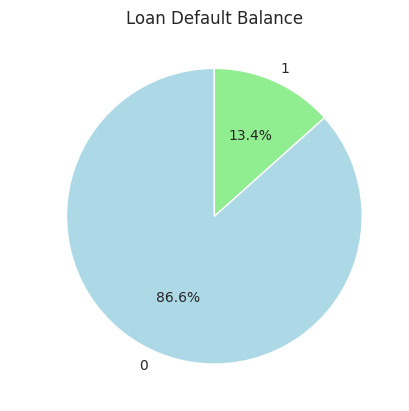

In [50]:
# Target value balance
Loan_Data_df['default'].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightblue", "lightgreen", "salmon", "lightcoral"]
)
plt.title("Loan Default Balance")
plt.ylabel(" ")
plt.show()

In [51]:
# Splitting the data into training and testing
X = Loan_Data_df.drop('default', axis=1)
y = Loan_Data_df['default']

In [52]:
#@title Training

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [54]:
#@title Initializing Random Forest

RFmodel = RandomForestClassifier(n_estimators=100)

# Fit the model
RFmodel.fit(X_train, y_train)

# Predict the model
y_pred = RFmodel.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Print classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.995710455764075
Confusion Matrix:
[[1614    2]
 [   6  243]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1616
           1       0.99      0.98      0.98       249

    accuracy                           1.00      1865
   macro avg       0.99      0.99      0.99      1865
weighted avg       1.00      1.00      1.00      1865



In [57]:
# Function to predict the probability of default and expected loss
def predict_default_probability(credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding, income, years_employed, fico_score):
    input_data = pd.DataFrame([[credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding, income, years_employed, fico_score]],
                              columns=X.columns)
    probability_of_default = RFmodel.predict_proba(input_data)[0][1]
    expected_loss = probability_of_default * loan_amt_outstanding * 0.9  # Assuming a recovery rate of 10%
    return probability_of_default, expected_loss

In [58]:
# example of usage
probability_of_default, expected_loss = predict_default_probability(1, 5000, 10000, 60000, 5, 650)
print(f"Probability of Default: {probability_of_default}")
print(f"Expected Loss: {expected_loss}")

Probability of Default: 0.0
Expected Loss: 0.0


##The model achieved high accuracy, and the function can be used to predict the probability of default and the expected loss for any given loan.

In [60]:
# Initialize a Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict (X_test)
y_pred_dt = dt_model.predict(X_test)

# Confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree Confusion Matrix:")
print(conf_matrix_dt)

# Evaluate the model's performance using metrics like accuracy, confusion matrix, etc.
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Confusion Matrix:
[[1612    4]
 [   6  243]]
Decision Tree Accuracy: 0.9946380697050938
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1616
           1       0.98      0.98      0.98       249

    accuracy                           0.99      1865
   macro avg       0.99      0.99      0.99      1865
weighted avg       0.99      0.99      0.99      1865



In [61]:
# Future importance & Decision Tree
from sklearn.tree import plot_tree

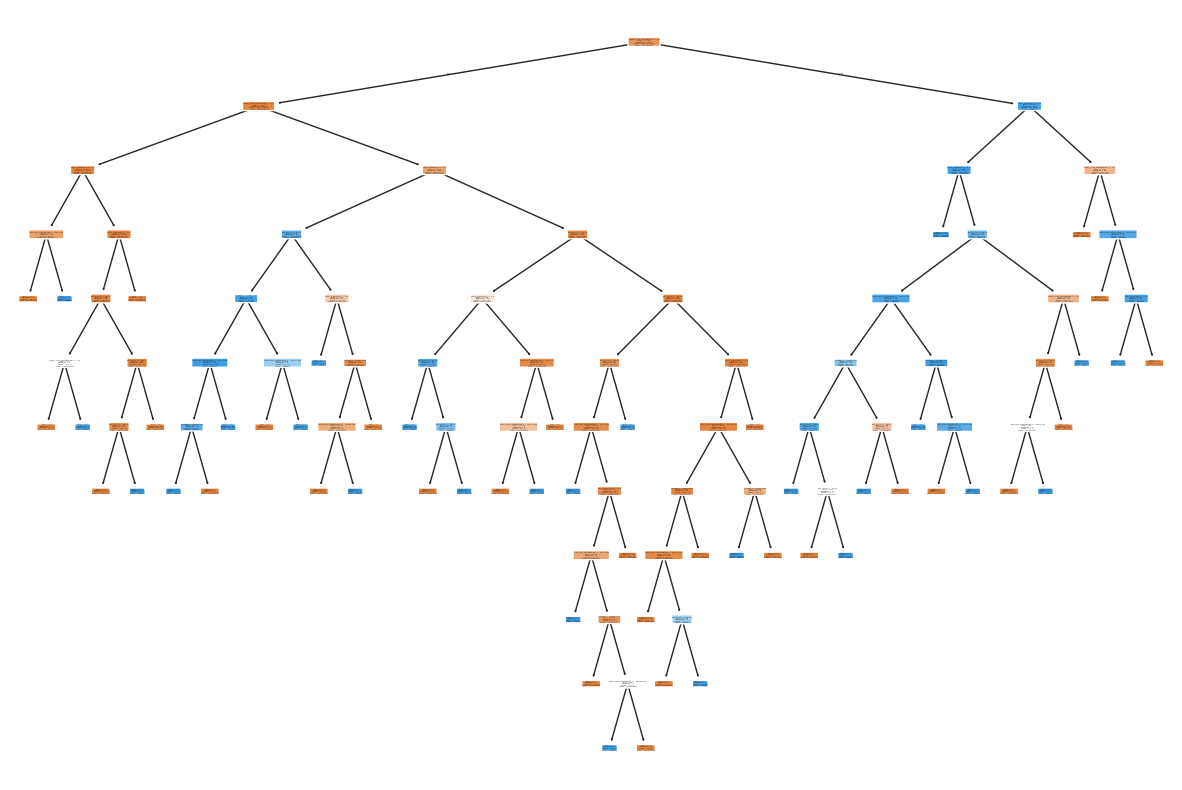

In [62]:
plt.figure(figsize=(15, 10))
plot_tree(dt_model, filled=True, rounded=True, feature_names=X.columns, class_names=['No Default', 'Default'])
plt.show()

credit_lines_outstanding: 0.8554
years_employed: 0.1004
fico_score: 0.0271
total_debt_outstanding: 0.0067
loan_amt_outstanding: 0.0057
income: 0.0046


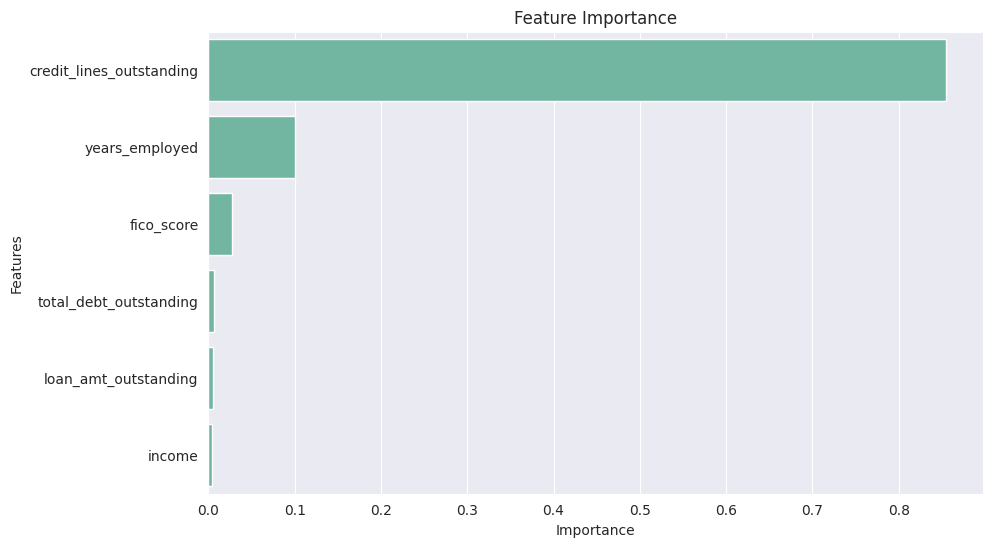

In [63]:
# Importance
feature_importances = dt_model.feature_importances_

# sort in descending order

features = sorted(zip(feature_importances, X.columns), reverse=True)

# Print it

for importance, feature in features:
    print(f"{feature}: {importance:.4f}")

# Plot Importance

plt.figure(figsize=(10, 6))
sns.barplot(x=[importance for importance, feature in features], y=[feature for importance, feature in features])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

In [64]:
# Function to predict the probability of default and expected loss
def predict_default_probability(credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding, income, years_employed, fico_score):
    input_data = pd.DataFrame([[credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding, income, years_employed, fico_score]],
                              columns=X.columns)
    probability_of_default = dt_model.predict_proba(input_data)[0][1]
    expected_loss = probability_of_default * loan_amt_outstanding * 0.9  # Assuming a recovery rate of 10%
    return probability_of_default, expected_loss

In [65]:
# Example of usage
probability_of_default, expected_loss = predict_default_probability(1, 5000, 10000, 60000, 5, 650)
print(f"Probability of Default: {probability_of_default}")
print(f"Expected Loss: {expected_loss}")

Probability of Default: 0.0
Expected Loss: 0.0


In [66]:
# Initialize a Logistic Regression model
logreg_model = LogisticRegression(random_state=42)

# Train the model
logreg_model.fit(X_train, y_train)

# Predict (X_test)
y_pred_logreg = logreg_model.predict(X_test)

# Confusion matrix
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Logistic Regression Confusion Matrix:")
print(conf_matrix_logreg)

# Evaluate the model's performance using metrics like accuracy, confusion matrix, etc.
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {accuracy_logreg}")
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Confusion Matrix:
[[1605   11]
 [  20  229]]
Logistic Regression Accuracy: 0.9833780160857909
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1616
           1       0.95      0.92      0.94       249

    accuracy                           0.98      1865
   macro avg       0.97      0.96      0.96      1865
weighted avg       0.98      0.98      0.98      1865



In [67]:
from logging import log
# Function to predict the probability of default and expected loss
def predict_default_probability(credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding, income, years_employed, fico_score):
    input_data = pd.DataFrame([[credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding, income, years_employed, fico_score]],
                              columns=X.columns)
    prediction = logreg_model.predict(input_data)
    probability_of_default = logreg_model.predict_proba(input_data)[0][1]
    expected_loss = probability_of_default * loan_amt_outstanding * 0.9  # Assuming a recovery rate of 10%
    return prediction, probability_of_default, expected_loss

In [68]:
# Example of usage
prediction, probability_of_default, expected_loss = predict_default_probability(1, 5000, 10000, 60000, 5, 650)
print(f"Prediction: {prediction}")
print(f"Probability of Default: {probability_of_default}")

Prediction: [0]
Probability of Default: 0.0038645603240346923


## Advance model to handle class imbalance issue perfectly

In [69]:
# Build XGBoost model

from xgboost import XGBClassifier

# Initialize an XGBoost model
xgb_model = XGBClassifier(random_state=42, scale_pos_weight= (y_train.value_counts()[0] / y_train.value_counts()[1])) # Handling Class imbalance


# Train the model
xgb_model.fit(X_train, y_train)

# Predict (X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:")
print(conf_matrix_xgb)

# Evaluate the model's performance using metrics like accuracy, confusion matrix, etc.
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb}")
print(classification_report(y_test, y_pred_xgb))

XGBoost Confusion Matrix:
[[1612    4]
 [   2  247]]
XGBoost Accuracy: 0.9967828418230563
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1616
           1       0.98      0.99      0.99       249

    accuracy                           1.00      1865
   macro avg       0.99      0.99      0.99      1865
weighted avg       1.00      1.00      1.00      1865



In [70]:
# Function to predict the probability of default and expected loss
def predict_default_probability(credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding, income, years_employed, fico_score):
    input_data = pd.DataFrame([[credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding, income, years_employed, fico_score]],
                              columns=X.columns)
    prediction = xgb_model.predict(input_data)
    probability_of_default = xgb_model.predict_proba(input_data)[0][1]
    expected_loss = probability_of_default * loan_amt_outstanding * 0.9  # Assuming a recovery rate of 10%
    return prediction, probability_of_default, expected_loss

# Example of usage
prediction, probability_of_default, expected_loss = predict_default_probability(1, 5000, 10000, 60000, 5, 650)
print(f"Prediction: {prediction}")
print(f"Probability of Default: {probability_of_default}")
print(f"Expected Loss: {expected_loss}")

Prediction: [0]
Probability of Default: 5.630390660371631e-06
Expected Loss: 0.02533675730228424


## XGBoost Model Interpretation

The code demonstrates the use of an XGBoost classifier for predicting loan default. See brief interpretation:

**1. Handling Class Imbalance:**
   - XGBoost is initialized with `scale_pos_weight` parameter. This addresses the class imbalance issue in the dataset, ensuring the model is not biased towards the majority class.
**2. Model Training:**
   - The `xgb_model.fit(X_train, y_train)` trains the XGBoost model using the training data.
**3. Prediction:**
   - `y_pred_xgb = xgb_model.predict(X_test)` makes predictions using the trained XGBoost model on the test data.
**4. Model Evaluation:**
   - `accuracy_xgb`, `confusion_matrix_xgb`, and `classification_report(y_test, y_pred_xgb)` evaluate the model's performance by calculating accuracy, confusion matrix, and precision/recall metrics.
**5. Prediction Function:**
   - The `predict_default_probability` function allows you to input new loan features and obtain a prediction of default probability and the expected loss.


**XGBoost is a powerful gradient boosting algorithm that creates an ensemble of decision trees to improve predictive accuracy.** It handles class imbalance effectively and is well-suited for complex classification problems like loan default prediction like this problem.

___________________________

***NB:***

- More advance issues like deploying SMOTE-Synthetic Minority Oversampling Techniques an be adopted to balance the data before deploying the model. Its disadvantage must be factored in this problem as well.